In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import ast
import sys
sys.path.append('../no_degeneracy/')
sys.path.append('../no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par

import seaborn as sns
import pyrenn
sns.set(style='ticks')

from pickle import load

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy.interpolate import griddata
from scipy.stats import spearmanr
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

colors_figures = {
'4e-3x': ['#fee0d2', '#deebf7'],
'2x':    ['#fc9272', '#9ecae1'],
'1x':    ['#de2d26', '#3182bd'],
'ann' : '#de2d26', 
'bms' : '#3182bd',
'data': sns.color_palette("colorblind")[7],
'noise': sns.color_palette("colorblind")[7]
}


#Text sizes  
#--------------------------------
size_axis=16;size_ticks=14;
size_title=16;
line_w=3;marker_s=8;m_size=10
size_legend=6
#--------------------------------

#Errors nn 
#--------------------------------------------------------------------------
def compute_errors_ann(df_function):
    
    #Validation and train borders
    n_points=int(len(df_function.index))
    
    train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
    train_size_ann=int(n_points*train_fraction)
    train_size_bms=train_size_ann + int(n_points*valid_fraction)
    train_border=df_function.loc[train_size_bms-1]['x1']

    #compute errors
    #ann errors
    rmse_nn_tr=root_mean_squared_error(df_function.loc[:train_size_bms-1]['ymodel'],df_function.loc[:train_size_bms -1]['y'])
    rmse_nn_tt=root_mean_squared_error(df_function.loc[train_size_bms-1:]['ymodel'],df_function.loc[train_size_bms -1:]['y'])


    return rmse_nn_tr, rmse_nn_tt, train_border
#--------------------------------------------------------------------------

#Errors bms 
#--------------------------------------------------------------------------
def compute_errors_bms(df_function):
    
    #Validation and train borders
    n_points=int(len(df_function.index))
    
    train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
    train_size_ann=int(n_points*train_fraction)
    train_size_bms=train_size_ann + int(n_points*valid_fraction)
    train_border=df_function.loc[train_size_bms-1]['x1']

    #bms errors
    try:
        rmse_mdl_tr=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ybms'],dplot.loc[:train_size_bms-1]['y'])
    except ValueError:
        rmse_mdl_tr=np.inf
    try:
        rmse_mdl_tt =root_mean_squared_error(dplot.loc[train_size_bms-1:]['ybms'],dplot.loc[train_size_bms-1:]['y'])
    except ValueError:
        rmse_mdl_tet=np.inf


    return rmse_mdl_tr, rmse_mdl_tt
#--------------------------------------------------------------------------

#Append indices from the approximation dataset that need to be removed from the interpolation dataset
def rows_to_remove(function_name, index_length,step):
    n0=0 #initial index
    
    if function_name=='10':
        n_points_interpolation=int(np.sqrt(index_length))  #number of rows or columns in the interpolation grid
        n_points_row=int(n_points_interpolation/5)         #number of rows or columns in the approximation grid

        print(n_points_interpolation)
        print(n_points_row)
        
        for i in range(n_points_row):
            print(n0)
            a1=np.arange(n0,n0+n_points_interpolation,step)#Get indices in the interpolation column/row that exist in the approximation
            n0=a1[-1] + n_points_interpolation*4 + 5 #Hop over row/column indices of the interpolation grid that dont exist in the approximation grid
            
            try:
                approximation_indices=np.append(approximation_indices,a1) #append indices to remove from each set of columns/rows
            except NameError:
                approximation_indices=a1 #initialize array

    else:
        approximation_indices=np.arange(n0,n0+n_points_int,step)#Get indices in the interpolation column/row that exist in the approximation

    return approximation_indices

In [21]:
#ANN architecture                                                                                   
#--------------------------------------------------                                                 
ILS, NL, LS, OLS = 1, 7,12,1

architecture=[ILS] + NL*[LS] + [OLS]
net_architecture='ILS%s_NL%s_LS%s' % (ILS, NL, LS)
#--------------------------------------------------

#Input parameters
step=0.05 #0.1, 0.05, 0.025, 0.004
function='tanh'
n=9;sigma=0.02;realization=0

#Read nn interpolation data
interp_path = '../../data/alternative_experiments/%s/nns/%s/interpolations/' % (net_architecture, str(step)) 
interp_model= 'NN_no_overfit_%s_sigma_%s_r_%s_interpolation.csv' % (function, str(sigma), str(realization) )
model_interp=interp_path + interp_model


dhr=pd.read_csv(model_interp)

dnhr=dhr[dhr['rep']==n]
dnhr=dnhr[(dnhr['x1']>=-2.0) & (dnhr['x1']<=2.0)]
dnhr.set_index('Unnamed: 0', inplace=True)
dnhr.index.name = None
dnhr=dnhr.reset_index(drop=True)

display(dnhr)


#read nn approximation data
nn_path = '../../data/alternative_experiments/%s/nns/%s/approximations/' % (net_architecture, str(step)) 
nn_model= 'NN_no_overfit_%s_sigma_%s_r_%s.csv' % (function, str(sigma), str(realization) )
model_d=nn_path + nn_model


d=pd.read_csv(model_d)
dn=d[d['rep']==n]
dn.set_index('Unnamed: 0', inplace=True)
dn.index.name = None
dn=dn.reset_index(drop=True)

display(dn)

,x1,y,rep,ymodel
0,-1.99,0.924740,9.0,0.939694
1,-1.98,0.923755,9.0,0.936113
2,-1.97,0.922731,9.0,0.932532
3,-1.96,0.921667,9.0,0.928956
4,-1.95,0.920561,9.0,0.925389
...,...,...,...,...
395,1.96,0.723950,9.0,1.047258
396,1.97,0.704313,9.0,1.047176
397,1.98,0.683874,9.0,1.047090
398,1.99,0.662700,9.0,1.047000


,x1,y,rep,noise,y_noise,ymodel
0,-1.95,0.920561,9.0,-0.005323,0.915238,0.925389
1,-1.90,0.914323,9.0,-0.000383,0.913940,0.907863
2,-1.85,0.906732,9.0,-0.030225,0.876507,0.891372
3,-1.80,0.897606,9.0,-0.005439,0.892167,0.876760
4,-1.75,0.886958,9.0,-0.003870,0.883088,0.865002
...,...,...,...,...,...,...
75,1.80,0.919057,9.0,0.010054,0.929111,1.047847
76,1.85,0.880242,9.0,0.004835,0.885078,1.047831
77,1.90,0.822794,9.0,0.028537,0.851331,1.047652
78,1.95,0.742731,9.0,0.014097,0.756828,1.047335


In [34]:
#PLOT ANN INTERPOLATION ERRORS

dplot = deepcopy(dnhr)

dinterpolate=deepcopy(dplot)

#round values of x1 to two decimals to cross both dataframes
#-------------------------------------------------------------
significant_figures=2
dinterpolate=dinterpolate.round({'x1':significant_figures})
dn=dn.round({'x1':significant_figures})
dinterpolate=dinterpolate[-dinterpolate['x1'].isin(dn['x1'].tolist() )] #cross dataframes to get only high resolution points
#-------------------------------------------------------------
display(dinterpolate)

#ann interpolation errors
rmse_nn_train, rmse_nn_test, train_border = compute_errors_ann(dinterpolate)

#Define figure size in cm                                                                           
cm = 1/2.54 #convert inch to cm                                                                     
width = 10*cm; height=8*cm

fig=figure(figsize=(width,height), dpi=300)

plt.plot(dn['x1'], dn['y'],linewidth=line_w, markersize=2, color=colors_figures['data'],label='observed data')     
plt.plot(dnhr['x1'], dnhr['ymodel'],linewidth=line_w, color=colors_figures['ann'], label=\
         'ann. rmse interp= %.2E, rmse extrap= %.2E' % ( rmse_nn_train, rmse_nn_test))

plt.plot(dn['x1'], dn['y_noise'],'.',markersize=marker_s, linewidth=line_w, color=colors_figures['noise'],label=r'$\sigma$=' + str(sigma) )

plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)


plt.legend(loc='best', fontsize=size_legend)
#set limits and layout
sns.despine();plt.tight_layout()

,x1,y,rep,ymodel
0,-1.99,0.924740,9.0,0.939694
1,-1.98,0.923755,9.0,0.936113
2,-1.97,0.922731,9.0,0.932532
3,-1.96,0.921667,9.0,0.928956
5,-1.94,0.919410,9.0,0.921836
...,...,...,...,...
393,1.94,0.760613,9.0,1.047408
395,1.96,0.723950,9.0,1.047258
396,1.97,0.704313,9.0,1.047176
397,1.98,0.683874,9.0,1.047090


KeyError: 239

In [9]:
#Read BMS trace
NREP=50000
NPAR=10
path_bms='../../data/alternative_experiments/%s/MStraces/%s/' % (net_architecture, str(step)) 

filename='BMS_%s_%s_n_%s_sigma_%s_r_%s_trace_%s_prior_%s.csv' % \
(function, net_architecture, str(n), str(sigma), str(realization), str(NREP), str(NPAR)) 

trace=pd.read_csv(path_bms + filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])


#Parameters to read models
VARS = ['x1',]
x = dn[[c for c in VARS]].copy()


if NPAR==10:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')
elif NPAR==20:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np20.maxs200.2024-05-10 162907.551306.dat')

#Minimum description length model
#y=dn.y_noise
y=dn.y


minrow = trace[trace.H == min(trace.H)].iloc[0]
display(minrow)
minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)

t = Tree(
    variables=list(x.columns),
    parameters=['a%d' % i for i in range(NPAR)],
    x=x, y=y,
    prior_par=prior_par,
    max_size=200,
    from_string=minexpr,
)

t.set_par_values(deepcopy(minparvals))

FileNotFoundError: [Errno 2] No such file or directory: '../../data/alternative_experiments/ILS1_NL7_LS12/MStraces/0.05/BMS_tanh_ILS1_NL7_LS12_n_9_sigma_0.02_r_2_trace_50000_prior_10.csv'

1000
750
0.996000000000004


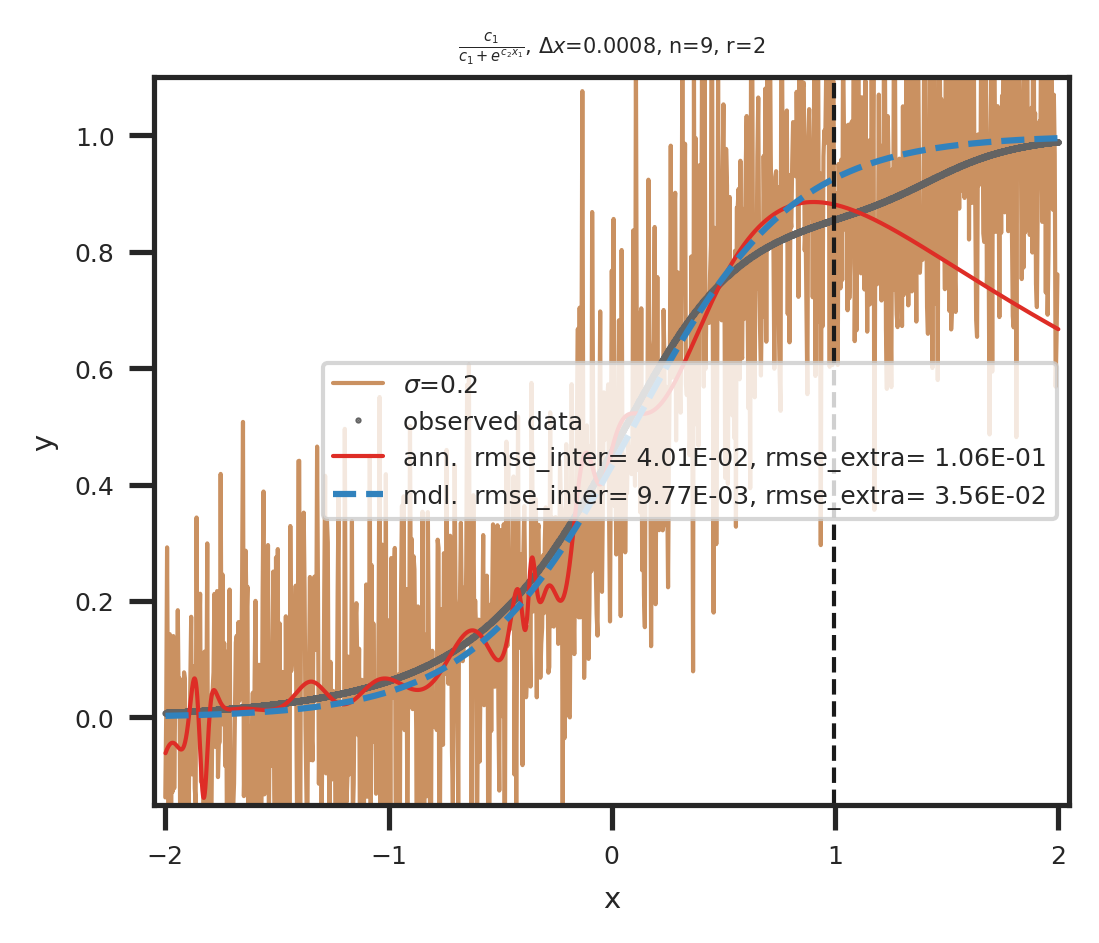

In [65]:
#BMS predictions
n_points=int(len(dn.index))
print(n_points)
train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
train_size_ann=int(n_points*train_fraction)
train_size_bms=train_size_ann + int(n_points*valid_fraction)

train_border=dn.loc[train_size_bms-1]['x1']
print(train_size_bms)
print(train_border)

dplot = deepcopy(dnhr)
dplot['ybms'] = t.predict(x)
dinterpolate=deepcopy(dplot)

#round values of x1 to two decimals to cross both dataframes
#-------------------------------------------------------------
significant_figures=2
if resolution=='4e-3x': #It seems it is better to consider 3 for very high resolutions
    significant_figures=3
dinterpolate=dinterpolate.round({'x1':significant_figures})
dn=dn.round({'x1':significant_figures})

dinterpolate=dinterpolate[-dinterpolate['x1'].isin(dn['x1'].tolist() )] #cross dataframes to get only high resolution points
#-------------------------------------------------------------

#Compute errors
#-------------------------------------------------------------
rmse_nn_train=root_mean_squared_error(dinterpolate.loc[:train_size_bms-1]['ymodel'],dinterpolate.loc[:train_size_bms -1]['y'])
rmse_nn_test=root_mean_squared_error(dinterpolate.loc[train_size_bms-1:]['ymodel'],dinterpolate.loc[train_size_bms -1:]['y'])
rmse_mdl_train=root_mean_squared_error(dinterpolate.loc[:train_size_bms-1]['ybms'],dinterpolate.loc[:train_size_bms-1]['y'])

try:
    rmse_mdl_test=root_mean_squared_error(dinterpolate.loc[train_size_bms-1:]['ybms'],dinterpolate.loc[train_size_bms-1:]['y'])
except ValueError:
    rmse_mdl_test=np.inf
#-------------------------------------------------------------

#Define figure size in cm                                                                           
cm = 1/2.54 #convert inch to cm                                                                     
width = 10*cm; height=8*cm

Extensions=['.png', '.pdf']

#Fonts and sizes                                                                                    
size_axis=7;size_ticks=6;size_title=5
line_w=1;marker_s=3 #width and marker size  

fig=figure(figsize=(width,height), dpi=300)                                                        

 

plt.plot(dn['x1'], dn['y_noise'],linewidth=line_w, markersize=2, color=color_noise,label=r'$\sigma$=' + str(sigma) ) 
plt.plot(dplot['x1'], dplot['y'],'.', markersize=1, color=color_data,label='observed data') 
plt.plot(dplot['x1'], dplot['ymodel'],linewidth=line_w, color=color_ann, label='ann.  rmse_inter= %.2E, rmse_extra= %.2E' % ( rmse_nn_train, rmse_nn_test)) 
plt.plot(dplot.x1, dplot.ybms, color=color_bms, linestyle='--',label='mdl.  rmse_inter= %.2E, rmse_extra= %.2E' % ( rmse_mdl_train, rmse_mdl_test))

plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')

plt.title('$%s$, $\Delta x$=%s, n=%d, r=%d' % ( t.latex(),resolutions_interp[resolution], n, realization),fontsize=size_title)
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.legend(loc='best', fontsize=size_ticks)


plt.xlim(-2.05,2.05);plt.ylim(-0.15,1.1)

Name_figure='interpolation_' + function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

    
for ext in Extensions:
        plt.savefig('../../results/' + Name_figure +ext,dpi=300)

plt.show()